#⚽ 5.2.2 SoccerTrack Challenge 2025 コード例による選手追跡

このノートブックでは、[SoccerTrack Challenge 2025](https://sites.google.com/g.sp.m.is.nagoya-u.ac.jp/stc2025) のベースラインを紹介し、選手追跡について学びます。

## 概要

このベースラインは、Deep-EIoU multi-object tracking (MOT) のGitHub公式コードを、SoccerTrack Challenge 2025によって提供されるサッカーの試合動画に適用したものです。トラッキング結果は、Ground truthアノテーションとHOTAメトリックを使用して評価されます。さらに、MOT出力の視覚化も定性分析のために提供されます。

![STC](https://drive.google.com/uc?export=view&id=1dpd9PZumzV3vjx47ZHyUJBg5KrYdkVIp)

## パイプラインの概要

1. **トラッキング**
[Deep-EIoU](https://github.com/hsiangwei0903/Deep-EIoU) をコンペティション動画で実行し、MOTChallenge形式のトラッキング出力を生成します。
2. **評価**
提供されたGround truthと[TrackEval](https://github.com/JonathonLuiten/TrackEval)ツールキットを使用し、HOTAを主要なメトリックとしてトラッキングパフォーマンスを評価します。
3. **視覚化**
トラッキング結果をフレームごとに視覚化し、トラッキング品質の解釈を支援します。

## このノートブックの実行手順：
1. Deep-EIoU の依存関係のインストール
2. SoccerTrack Challenge 2025 動画データのダウンロード
3. トラッキングの実行
4. TrackEval の依存関係のインストール
5. HOTA 評価の準備
6. 結果の評価


## クレジット
*   Authors: Li Yin & Keisuke Fujii
*   Affiliation: Nagoya University
*   Last updated: 2025-12-07
*   License: CC BY 4.0


# 1. Deep-EIoU の依存関係のインストール
開始する前に、Colabのランタイムを GPU に設定してください（このファイルをドライブにコピーしたらおそらくGPUの設定は保存されています）。
ランタイム > ランタイムのタイプを変更 > ハードウェアアクセラレータ > GPU
から変更できます。
その後、下記のコードブロックを実行してください。

In [1]:
# Install Python 3.7 and pip
!sudo apt-get install python3.7 python3.7-dev python3.7-distutils -y
!wget https://bootstrap.pypa.io/pip/3.7/get-pip.py
!python3.7 get-pip.py

# Install PyTorch (CUDA 11.6), and other dependencies
!python3.7 -m pip install torch==1.13.0+cu116 torchvision==0.14.0+cu116 \
torchaudio==0.13.0 --index-url https://download.pytorch.org/whl/cu116

# Install cython-bbox and gdown
!python3.7 -m pip install cython-bbox gdown

# Clone Deep-EIoU repo
!git clone https://github.com/hsiangwei0903/Deep-EIoU.git

# Install requirements for ReID
%cd /content/Deep-EIoU/Deep-EIoU/reid
!python3.7 -m pip install -r requirements.txt

# Go back to main directory
%cd /content/Deep-EIoU/Deep-EIoU

# Download the Detector and ReID model
!gdown --fuzzy 'https://drive.google.com/file/d/1834kh10-X0Tu743fgmN7jXPVDKgq4ZqR/view?usp=drive_link' --output checkpoints/best_ckpt.pth.tar
!gdown --fuzzy 'https://drive.google.com/file/d/14zzlm1nI9Ws_Il9RYNChwPC7Fsul7xwl/view?usp=drive_link' --output checkpoints/sports_model.pth.tar-60

# Install torchreid separately
!python3.7 -m pip install git+https://github.com/KaiyangZhou/deep-person-reid.git  # torchreid

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libpython3.7 libpython3.7-dev libpython3.7-minimal libpython3.7-stdlib
  python3.7-lib2to3 python3.7-minimal
Suggested packages:
  python3.7-venv binfmt-support
The following NEW packages will be installed:
  libpython3.7 libpython3.7-dev libpython3.7-minimal libpython3.7-stdlib
  python3.7 python3.7-dev python3.7-distutils python3.7-lib2to3
  python3.7-minimal
0 upgraded, 9 newly installed, 0 to remove and 41 not upgraded.
Need to get 11.1 MB of archives.
After this operation, 41.8 MB of additional disk space will be used.
Get:1 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 libpython3.7-minimal amd64 3.7.17-1+jammy1 [608 kB]
Get:2 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 python3.7-minimal amd64 3.7.17-1+jammy1 [1,837 kB]
Get:3 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubunt

# 2.SoccerTrack Challenge 2025 動画データのダウンロード
SoccerTrack Challenge 2025 データセットは https://drive.google.com/drive/folders/1_o78gcL4j0xHxbRjSR1Evs4VLXCr2ncD から入手できます。

In [2]:
# Download the Video Data
%cd /content/Deep-EIoU/Deep-EIoU
!gdown --fuzzy 'https://drive.google.com/file/d/1bC1C5lOM-2AKX2Jmk-9Yk7klzYIh0uEF/view?usp=drive_link' # video 117093.mp4
# !gdown --fuzzy 'https://drive.google.com/file/d/1DQj5-kiU4VySymDXZuV84-nU1AZ4HZaj/view?usp=drive_link'# video 117092.mp4

/content/Deep-EIoU/Deep-EIoU
Downloading...
From (original): https://drive.google.com/uc?id=1bC1C5lOM-2AKX2Jmk-9Yk7klzYIh0uEF
From (redirected): https://drive.google.com/uc?id=1bC1C5lOM-2AKX2Jmk-9Yk7klzYIh0uEF&confirm=t&uuid=625e174b-8698-46e7-a54a-2285332e7229
To: /content/Deep-EIoU/Deep-EIoU/117093.mp4
100% 305M/305M [00:03<00:00, 77.5MB/s]


In [3]:
# Trim the first 20 seconds of the 4-min video
!ffmpeg -i /content/Deep-EIoU/Deep-EIoU/117093.mp4 -ss 00:00:00 -t 00:00:20 -c copy /content/Deep-EIoU/Deep-EIoU/117093_trimmed.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

# 3.トラッキングの実行

📍出力パス:
- トラッキング結果のビデオの場所:
/content/Deep-EIoU/Deep-EIoU/YOLOX_outputs/yolox_x_ch_sportsmot/track_vis/(timestamp)/117093.mp4
- トラッキング結果txtファイルの場所:
/content/Deep-EIoU/Deep-EIoU/YOLOX_outputs/yolox_x_ch_sportsmot/track_vis/*.txt
- モデルの異なるパラメータを試す場合は、出力 txt ファイルとビデオファイルを保存してください。

オプション: https://github.com/hsiangwei0903/Deep-EIoU/blob/main/Deep-EIoU/tools/demo.py#L81-L95

# トラッキングに関するパラメータ
    parser.add_argument("--track_high_thresh", type=float, default=0.6, help="tracking confidence threshold")
    parser.add_argument("--track_low_thresh", default=0.1, type=float, help="lowest detection threshold valid for tracks")
    parser.add_argument("--new_track_thresh", default=0.7, type=float, help="new track thresh")
    parser.add_argument("--track_buffer", type=int, default=60, help="the frames for keep lost tracks")
    parser.add_argument("--match_thresh", type=float, default=0.8, help="matching threshold for tracking")
    parser.add_argument("--aspect_ratio_thresh", type=float, default=1.6, help="threshold for filtering out boxes of which aspect ratio are above the given value.")
    parser.add_argument('--min_box_area', type=float, default=10, help='filter out tiny boxes')
    parser.add_argument("--nms_thres", type=float, default=0.7, help='nms threshold')
    parser.add_argument("--mot20", dest="mot20", default=False, action="store_true", help="test mot20.")

  # ReIDに関するパラメータ
    parser.add_argument("--with-reid", dest="with_reid", default=True, action="store_true", help="use Re-ID flag.")
    parser.add_argument('--proximity_thresh', type=float, default=0.5, help='threshold for rejecting low overlap reid matches')
    parser.add_argument('--appearance_thresh', type=float, default=0.25, help='threshold for rejecting low appearance similarity reid matches')

For details, see the [DeepEIoU paper](https://openaccess.thecvf.com/content/WACV2024W/RWS/papers/Huang_Iterative_Scale-Up_ExpansionIoU_and_Deep_Features_Association_for_Multi-Object_Tracking_WACVW_2024_paper.pdf):

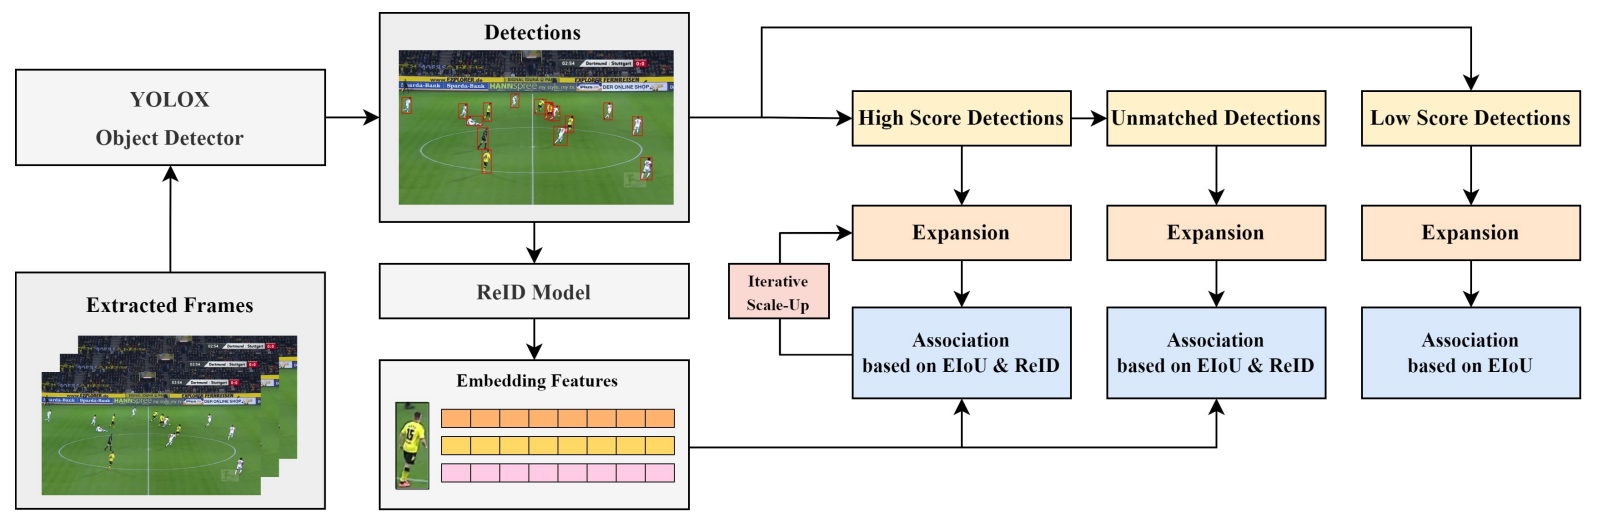

In [4]:
# ▶️ Run tracking inference (20 sec x 25 fps)
!python3.7 tools/demo.py --path 117093_trimmed.mp4 --save_result True # --with-reid

2025-12-26 05:11:51.709 | INFO     | __main__:main:265 - Args: Namespace(appearance_thresh=0.25, aspect_ratio_thresh=1.6, ckpt=None, conf=None, device=device(type='cuda'), exp_file='yolox/yolox_x_ch_sportsmot.py', experiment_name='yolox_x_ch_sportsmot', fp16=False, fps=30, fuse=False, match_thresh=0.8, min_box_area=10, mot20=False, name=None, new_track_thresh=0.7, nms=None, nms_thres=0.7, path='117093_trimmed.mp4', proximity_thresh=0.5, save_result='True', track_buffer=60, track_high_thresh=0.6, track_low_thresh=0.1, trt=False, tsize=None, with_reid=True)
/usr/local/lib/python3.7/dist-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
2025-12-26 05:12:02.645 | INFO     | __main__:main:275 - Model Summary: Params: 99.00M, Gflops: 793.21
2025-12-26 05:12:02.648 

# 4. TrackEval の依存関係をインストール
pycocotools のインストールエラーが表示されますが、無視してください。

In [5]:
 #Clone TrackEval and install dependencies
%cd /content/
!git clone https://github.com/JonathonLuiten/TrackEval.git
!python3.7 -m pip install lap cython motmetrics
%cd /content/TrackEval/
!python3.7 -m pip install -r requirements.txt

# Removed mkdir commands from here, they are moved to the next cell to ensure execution order.

/content
Cloning into 'TrackEval'...
remote: Enumerating objects: 924, done.
remote: Counting objects: 100% (378/378), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 924 (delta 344), reused 319 (delta 319), pack-reused 546 (from 1)
Receiving objects: 100% (924/924), 393.80 KiB | 8.75 MiB/s, done.
Resolving deltas: 100% (619/619), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 40.8 MB/s eta 0:00:00
/content/TrackEval
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of imageio to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of imageio to determine which version is compatible with other requ

# 5.HOTA評価の準備
公式コードを使用してHOTAを計算する場合、関連ファイルは指定されたデータセット形式に従って整理する必要があります。
以下に関連コードを提供します。詳細については、GitHubのページ[TrackEval](https://github.com/JonathonLuiten/TrackEval)を参照してください。

**注意: gt.txtファイルとトラッキング結果のtxtファイルのフレームインデックスは1から始まる必要があります。また、このコードでは最初の20秒だけgt.txtを切り取っています。**

In [6]:
# Prepare directories for GT and predictions
!mkdir -p /content/TrackEval/data/gt/mot_challenge/mydataset/117093/gt
!mkdir -p /content/TrackEval/data/trackers/mot_challenge/mydataset/my_tracker/data

# Download GT file (ground truth)
!gdown --fuzzy 'https://drive.google.com/file/d/1E34_ZbiIAC558niv_v0jHUxML6tfxBYu/view?usp=drive_link' \
--output /content/TrackEval/data/gt/mot_challenge/mydataset/117093/gt/gt.txt # 117093
#!gdown --fuzzy 'https://drive.google.com/file/d/1cQeC4c0FG8i8Xayw3LdzhEU5p42s7zD1/view?usp=drive_link' \
#--output /content/TrackEval/data/gt/mot_challenge/mydataset/117093/gt/gt.txt # 117092

# Copy prediction results from Deep-EIoU
import glob, shutil, os
files_path = glob.glob('/content/Deep-EIoU/Deep-EIoU/YOLOX_outputs/yolox_x_ch_sportsmot/track_vis/*.txt')
for file in files_path:
    shutil.copy(file, "/content/TrackEval/data/trackers/mot_challenge/mydataset/my_tracker/data/117093.txt")

# Create seqmap (defines which sequences are used)
seqmap_path = "/content/TrackEval/data/gt/mot_challenge/mydataset/seqmaps/"
os.makedirs(seqmap_path, exist_ok=True)
with open(os.path.join(seqmap_path, "mydataset-test.txt"), "w") as f:
    f.write("name\n117093")

# Generate seqinfo.ini (basic video metadata)
ini_content = (
    "[Sequence]\n"
    "name=117093\n"
    "imDir=img1\n"
    "frameRate=25\n" # Corrected to 25 FPS based on video
    "seqLength=500\n" # Corrected to 500 frames (20 seconds * 25 FPS)
    "imWidth=4096\n"
    "imHeight=1080\n"
    "imExt=.jpg"
)
with open("/content/TrackEval/data/gt/mot_challenge/mydataset/117093/seqinfo.ini", "w") as f:
    f.write(ini_content)

# Format .txt files to comply with TrackEval (frame starts at 1, class ID = 1, space-separated)
def clean_and_trim_track_file(file_path, max_frame, is_gt=False):
    processed_detections = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split(',')
        if parts and parts[0].isdigit():
            frame_id = int(parts[0])

            # Ensure frame_id is 1-indexed, increment if it's 0
            if frame_id == 0:
                frame_id = 1

            if frame_id <= max_frame:
                # Ensure class ID is 1 for GT or predictions if it's not already.
                # GT format: frame, ID, bb_left, bb_top, bb_width, bb_height, conf, class_id, visibility
                # For MOTChallenge, class_id=1 for pedestrian. Let's force it.
                if is_gt: # GT usually has 9 fields
                    if len(parts) >= 8: # Ensure there's a class_id field
                        parts[7] = '1'
                    # Keep other GT specific logic if any
                else: # Prediction format: frame, ID, bb_left, bb_top, bb_width, bb_height, conf, class_id, -1, -1
                    # Deep-EIoU prediction usually has 8 fields: frame, id, x, y, w, h, score, class
                    # We need to make sure the class_id (8th field if it exists) is set to 1.
                    if len(parts) >= 8:
                        parts[7] = '1' # class_id
                    else:
                        # If class_id is missing in prediction, append it (TrackEval expects it)
                        parts.append('1') # default to 1

                    track_id = int(parts[1])
                    conf_score = float(parts[6]) # Confidence score is typically the 7th field (index 6)

                    if frame_id not in processed_detections:
                        processed_detections[frame_id] = {}

                    # Deduplicate tracker IDs by keeping the detection with the highest confidence score
                    if track_id not in processed_detections[frame_id] or \
                       conf_score > processed_detections[frame_id][track_id]['conf']:
                        processed_detections[frame_id][track_id] = {
                            'conf': conf_score,
                            'line_parts': parts
                        }

                # If it's GT or a non-tracker-deduplicated prediction, just store the line for now
                if is_gt:
                    if frame_id not in processed_detections:
                        processed_detections[frame_id] = {}
                    # For GT, track_id must be unique by default. Just append.
                    track_id = int(parts[1])
                    processed_detections[frame_id][track_id] = {'line_parts': parts}

        # Non-data lines (if any) are currently skipped, but TrackEval usually expects only data.
        # If header lines were present, they would be lost here. Assuming pure data files.

    output_lines = []
    # Sort frames and then track_ids for consistent output
    for frame_id in sorted(processed_detections.keys()):
        for track_id in sorted(processed_detections[frame_id].keys()):
            parts = processed_detections[frame_id][track_id]['line_parts']
            parts[0] = str(frame_id) # Ensure frame_id is correctly set after potential 0->1 change
            output_lines.append(' '.join(parts) + '\n')

    with open(file_path, 'w', encoding='utf-8') as f:
        f.writelines(output_lines)

# Define the maximum frame for 20 seconds at 25 FPS
MAX_FRAME = 20 * 25 # 500 frames

# Apply cleaning and trimming to GT and prediction result files
gt_txt = '/content/TrackEval/data/gt/mot_challenge/mydataset/117093/gt/gt.txt'
pred_txt = '/content/TrackEval/data/trackers/mot_challenge/mydataset/my_tracker/data/117093.txt'

# Process and trim GT file
clean_and_trim_track_file(gt_txt, MAX_FRAME, is_gt=True)

# Process and trim prediction file (this was likely done in Deep-EIoU output, but ensuring consistency)
clean_and_trim_track_file(pred_txt, MAX_FRAME, is_gt=False)

Downloading...
From: https://drive.google.com/uc?id=1E34_ZbiIAC558niv_v0jHUxML6tfxBYu
To: /content/TrackEval/data/gt/mot_challenge/mydataset/117093/gt/gt.txt
100% 6.22M/6.22M [00:00<00:00, 44.0MB/s]


# 6. 結果の評価

HOTAおよびその他のメトリックの詳細な説明については、https://autonomousvision.github.io/hota-metrics/ を参照してください。

In [7]:
# Run evaluation
!python3.7 -m pip install matplotlib-inline
!python3.7 -m pip install ipython
%cd /content/TrackEval
!python3.7 scripts/run_mot_challenge.py \
  --BENCHMARK mydataset \
  --SPLIT_TO_EVAL test \
  --GT_FOLDER data/gt/mot_challenge/mydataset \
  --TRACKERS_FOLDER data/trackers/mot_challenge/mydataset \
  --TRACKERS_TO_EVAL my_tracker \
  --METRICS HOTA CLEAR Identity \
  --SKIP_SPLIT_FOL True

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.4/117.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.8/793.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 5.1 MB/s eta 0:00:00
/content/TrackEval

Eval Config:
USE_PARALLEL         : False                         
NUM_PARALLEL_CORES   : 8                             
BREAK_ON_ERROR       : True                          
RETURN_ON_ERROR      : False                         
LOG_ON_ERROR         : /content/TrackEval/error_log.txt
PRINT_RESULTS        : True                          
PRINT_ONLY_COMBINED  : False                         
PRINT_CONFIG         : True      